# ۴.۲ — تحلیل گروهی و آزمون فرضیه (دفترچه فرضیه‌های H1–H12)\n",
"\n",
"**پروژه:** پیش‌بینی نرخ عدم‌دریافت غذا $\\rho = NoRecv/Res$ در سلف‌های دانشگاه تهران، سطح تحلیل $(d,m,r,f)$ = (روز، وعده، سلف، نوع غذا).\n",
"\n",
"**جایگاه در WBS:** بند ۴.۲ (فاز ۴ — کاوش اکتشافی داده). فاز ۳ کامل و داده **قفل‌شده** است؛ این نوت‌بوک فقط از `data/processed/dataset_v1.csv` (فقط‌خواندنی) می‌خواند و هیچ فایلی در `data/raw/` یا `data/processed/` تغییر نمی‌دهد.\n",
"\n",
"## اصول حاکم بر این نوت‌بوک\n",
"\n",
"1. **پیش‌ثبت (Pre-registration):** فرضیه‌های H1 تا H12 (به‌جز H8/H9 که به agent دیگری برای بند ۴.۱۰ واگذار شده‌اند) دقیقاً به همان صورتی که در دفترچه‌ی WBS آمده‌اند، **پیش از دیدن نتیجه‌ی آزمون** نوشته شده‌اند. جهت آزمون (یک‌طرفه/دوطرفه) از خودِ متن فرضیه استخراج می‌شود، نه از داده — هرگونه انحراف از این ترتیب HARKing (Hypothesizing After the Results are Known) است.\n",
"2. **مسیر پیش‌فرض ناپارامتری:** چون $\\rho$ نرمال نیست (چولگی راست، کراندار در $[0,1]$، تراکم نزدیک صفر)، Mann-Whitney U / Kruskal-Wallis / Spearman / Levene به‌جای معادل‌های پارامتری‌شان استفاده می‌شوند.\n",
"3. **سه اشتباه ممنوع:**\n",
"   - هرگز فقط p-value گزارش نمی‌شود — همیشه اندازه‌ی اثر (Cliff's delta / rank-biserial / $\\eta^2$) و فاصله‌اطمینان bootstrap برای تفاوت میانه‌ها همراه آن می‌آید.\n",
"   - **تصحیح آزمون‌های چندگانه:** روی مجموعه‌ی p-value های سطح فرضیه (H1–H12 + یک آزمون تکمیلی pivot) تصحیح Benjamini-Hochberg (FDR) اعمال می‌شود. برای مقایسه‌های زوجی post-hoc (Dunn، در H2 و H6) به‌دلیل تعداد زیاد زوج‌ها (تا ۴۹۶ زوج در H6)، تصحیح FDR **درون همان خانواده‌ی مقایسه‌ای** با `scikit_posthocs.posthoc_dunn(..., p_adjust='fdr_bh')` اعمال می‌شود — این رویه‌ی استاندارد ادبیات post-hoc است و مانع رقیق‌شدن قدرت آزمون‌های سطح فرضیه توسط صدها مقایسه‌ی زوجی می‌شود؛ این تصمیم روش‌شناختی صریحاً یادداشت شده تا از ابهام جلوگیری شود.\n",
"   - **نقض استقلال (خودهمبستگی):** برای H1 و H6، آزمون علاوه بر داده‌ی خام سطح ردیف، روی داده‌ی تجمیع‌شده در سطح (سلف×روز) هم تکرار می‌شود تا پایداری نتیجه در برابر شبه‌تکرار (pseudo-replication) بررسی شود.\n",
"\n",
"## کدهای کمکی\n",
"\n",
"توابع اندازه‌ی اثر (Cliff's delta، $\\eta^2$)، فاصله‌اطمینان bootstrap، پیاده‌سازی دستی Mann-Kendall (چون `pymannkendall` نصب نیست) و ساخت فیچر `days_since_same_food` در فایل جدید `src/eda_lib/group_test_helpers.py` قرار دارند — هیچ فایل موجودی در `src/` تغییر نکرده است.

In [1]:
import sys
sys.path.insert(0, '/home/mvajhi/code/new_project')

from src.config import set_global_seed
set_global_seed()

from src.viz_fa import setup, fa
setup()

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp

from src.eda_lib.group_test_helpers import (
    cliffs_delta,
    eta_squared_kruskal,
    eta_squared_levene,
    bootstrap_median_diff_ci,
    mann_kendall,
    build_days_since_same_food,
    fdr_correct,
)

from src.config import DATA_PROCESSED, DATA_EXTERNAL, FIGURES_DIR

pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 140)

FIG_PREFIX = '4.2_'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name, fig=None):
    """ذخیره‌ی نمودار با پیشوند 4.2_ در reports/figures/."""
    fig = fig or plt.gcf()
    path = FIGURES_DIR / f'{FIG_PREFIX}{name}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print('saved:', path)

## بارگذاری داده و ساخت فیچرهای مورد نیاز فرضیه‌ها

`dataset_v1.csv` (سطح $(d,m,r,f)$، ۷٬۵۹۱ ردیف) به‌همراه `calendar_tehran.csv` (برای H3 و H7) لود می‌شود. فیچر `days_since_same_food` (لازم برای H5) اینجا ساخته می‌شود — این فیچر **صرفاً برای EDA توصیفی** است، نه ورودی نهایی مدل؛ نسخه‌ی leakage-safe آن (با رعایت قاعده‌ی برش اطلاعاتی بند ۴-۲ سند مسئله) در فاز ۵ به‌طور جداگانه ساخته خواهد شد.

**نکته‌ی برش اطلاعاتی:** این نوت‌بوک صرفاً EDA توصیفی روی داده‌ی گذشته است — هیچ فیچری برای پیش‌بینی آنلاین ساخته نمی‌شود، پس قاعده‌ی برش اطلاعاتی بند ۴-۲ سند مسئله اینجا نقض نمی‌شود (آن قاعده مخصوص فاز ۵ فیچرسازی مدل است).

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'dataset_v1.csv')
cal = pd.read_csv(DATA_EXTERNAL / 'calendar_tehran.csv')

# H3 نیازمند is_day_before_holiday (=is_holiday_any روز بعد، از پیش در calendar_tehran.csv محاسبه‌شده — src/data/calendar.py)
# H7 نیازمند is_exam_period
df = df.merge(
    cal[['date_gregorian', 'is_day_before_holiday', 'is_exam_period', 'is_holiday_any']],
    on='date_gregorian', how='left', validate='m:1'
)
assert df['is_day_before_holiday'].isnull().sum() == 0, 'join calendar ناقص بود'

# H5: فاصله‌ی روزی از آخرین سرو قبلی همان غذا در همان سلف (فقط سلف×غذا، بدون تفکیک وعده — طبق تعریف WBS)
df['days_since_same_food'] = build_days_since_same_food(df)

# ماه شمسی برای پیوت‌های 4.2.1
df['month_jalali'] = df['DateReserve'].str.slice(5, 7).astype(int)

MONTH_FA = {9: 'آذر', 10: 'دی', 11: 'بهمن', 12: 'اسفند', 1: 'فروردین', 2: 'اردیبهشت', 3: 'خرداد'}
DOW_FA = {0: 'شنبه', 1: 'یکشنبه', 2: 'دوشنبه', 3: 'سه‌شنبه', 4: 'چهارشنبه', 5: 'پنجشنبه', 6: 'جمعه'}
df['month_fa'] = df['month_jalali'].map(MONTH_FA)
df['dow_fa'] = df['DayOfWeek'].map(DOW_FA)

print('shape:', df.shape)
print('بازه‌ی تاریخ:', df['date_gregorian'].min(), '..', df['date_gregorian'].max())
print('تعداد رکورد با days_since_same_food نامعلوم (اولین سرو آن سلف/غذا):', df['days_since_same_food'].isnull().sum())
df[['DateReserve', 'Meal', 'RestaurantName', 'FoodName', 'FoodType', 'Res', 'rho', 'DayOfWeek',
    'is_day_before_holiday', 'is_exam_period', 'days_since_same_food']].head()

shape: (7591, 29)
بازه‌ی تاریخ: 2023-11-22 .. 2024-05-21
تعداد رکورد با days_since_same_food نامعلوم (اولین سرو آن سلف/غذا): 1340


,DateReserve,Meal,RestaurantName,FoodName,FoodType,Res,rho,DayOfWeek,is_day_before_holiday,is_exam_period,days_since_same_food
0,1402-09-01,dinner,ابوریحان,خوراک سالاد الویه,khorak,60.0,0.016667,4,False,True,NaN
1,1402-09-01,dinner,ابوریحان,چلوکباب تابه ای,berenji,96.0,0.031250,4,False,True,NaN
2,1402-09-01,dinner,ساختمان 6,خوراک سالاد الویه,khorak,262.0,0.064885,4,False,True,NaN
3,1402-09-01,dinner,ساختمان 6,چلوکباب تابه ای,berenji,551.0,0.063521,4,False,True,NaN
4,1402-09-01,dinner,ساختمان 71و72,خوراک سالاد الویه,khorak,427.0,0.091335,4,False,True,NaN


## ۴.۲.۱ جدول‌های محوری (Pivot Tables)

میانگین و میانه‌ی $\rho$ به تفکیک هرکدام از: سلف، وعده، روز هفته، نوع غذا، ماه — و سپس ۵ heatmap دوبعدی برای ترکیب‌های کلیدی.

In [3]:
def pivot_1d(col):
    g = df.groupby(col)['rho'].agg(mean='mean', median='median', std='std', count='count')
    return g.sort_values('mean', ascending=False)

piv_restaurant = pivot_1d('RestaurantName')
piv_meal = pivot_1d('Meal')
piv_dow = pivot_1d('dow_fa').reindex([DOW_FA[i] for i in range(7)])
piv_foodtype = pivot_1d('FoodType')
piv_month = pivot_1d('month_fa').reindex([MONTH_FA[m] for m in [9, 10, 11, 12, 1, 2, 3]])

print('--- به تفکیک وعده ---'); display(piv_meal)
print('--- به تفکیک روز هفته ---'); display(piv_dow)
print('--- به تفکیک نوع غذا ---'); display(piv_foodtype)
print('--- به تفکیک ماه (⚠️ خرداد فقط ۱ روز از بازه‌ی قفل‌شده را دارد، n کم) ---'); display(piv_month)
print('--- به تفکیک سلف (۳۲ سلف، مرتب‌شده نزولی) ---'); display(piv_restaurant)

--- به تفکیک وعده ---


,mean,median,std,count
Meal,,,,
lunch,0.102848,0.086454,0.088477,5426
dinner,0.079692,0.063898,0.074034,2165


--- به تفکیک روز هفته ---


,mean,median,std,count
dow_fa,,,,
شنبه,0.083102,0.073096,0.066497,1422
یکشنبه,0.075195,0.063665,0.068343,1274
دوشنبه,0.096003,0.080745,0.092977,1495
سه‌شنبه,0.100063,0.087109,0.074100,1420
چهارشنبه,0.125419,0.106184,0.098440,1406
پنجشنبه,0.090084,0.074027,0.093274,488
جمعه,0.124481,0.070194,0.162910,86


--- به تفکیک نوع غذا ---


,mean,median,std,count
FoodType,,,,
khorak,0.098672,0.082569,0.084917,3700
berenji,0.093936,0.078431,0.085509,3891


--- به تفکیک ماه (⚠️ خرداد فقط ۱ روز از بازه‌ی قفل‌شده را دارد، n کم) ---


,mean,median,std,count
month_fa,,,,
آذر,0.090548,0.075066,0.067082,1528
دی,0.091171,0.075373,0.078770,1578
بهمن,0.095458,0.082153,0.076721,1187
اسفند,0.130625,0.100492,0.124566,1066
فروردین,0.096608,0.083723,0.082755,490
اردیبهشت,0.083623,0.071429,0.076136,1671
خرداد,0.123054,0.117530,0.065252,71


--- به تفکیک سلف (۳۲ سلف، مرتب‌شده نزولی) ---


,mean,median,std,count
RestaurantName,,,,
دوره حوزه علوم انسانی ( مهر),0.496769,0.285714,0.478583,7
کارآفرینی,0.176934,0.151923,0.126148,142
علوم اجتماعی,0.152861,0.126904,0.140705,197
علوم و فناوری های میان رشته ای,0.147704,0.115385,0.156224,192
هنرهای زیبا,0.139774,0.119792,0.074847,198
مهر,0.137321,0.129753,0.045044,198
ساختمان 71و72,0.132136,0.111293,0.095831,270
ژئوفیزیک,0.130070,0.099010,0.140452,187
دامپزشکی تهران,0.126950,0.121212,0.077297,195


### Heatmap ۱ — سلف × وعده (میانگین $\rho$)

بسیاری از سلف‌های «دانشگاه» فقط ناهار سرو می‌کنند (سلول خالی/خاکستری = بدون داده) — این نامتوازنی مستقیماً روی تفسیر H1 اثر می‌گذارد (بخش H1 پایین‌تر).

/home/mvajhi/code/new_project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.canvas.draw()
/tmp/ipykernel_427465/2012748832.py:11: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  plt.tight_layout()
/tmp/ipykernel_427465/2359381861.py:42: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.savefig(path, dpi=150, bbox_inches='tight')


saved: /home/mvajhi/code/new_project/reports/figures/4.2_heatmap_restaurant_meal.png


/home/mvajhi/code/new_project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.canvas.print_figure(bytes_io, **kw)


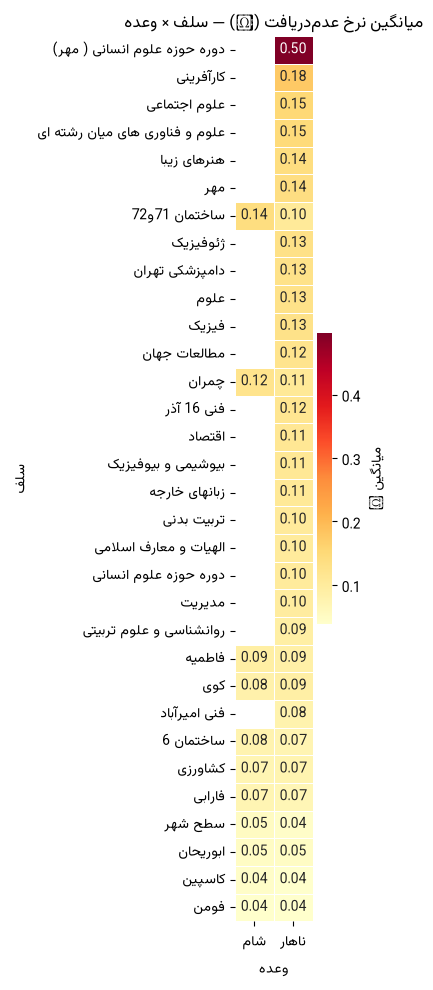

In [4]:
pt1 = df.pivot_table(index='RestaurantName', columns='Meal', values='rho', aggfunc='mean')
pt1 = pt1.reindex(piv_restaurant.index)  # مرتب‌شده طبق میانگین کلی

fig, ax = plt.subplots(figsize=(4, 10))
sns.heatmap(pt1, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.4,
            cbar_kws={'label': fa('میانگین ρ')}, ax=ax)
ax.set_title(fa('میانگین نرخ عدم‌دریافت (ρ) — سلف × وعده'))
ax.set_xlabel(fa('وعده')); ax.set_ylabel(fa('سلف'))
ax.set_xticklabels([fa('شام' if t.get_text()=='dinner' else 'ناهار') for t in ax.get_xticklabels()])
ax.set_yticklabels([fa(t.get_text()) for t in ax.get_yticklabels()])
plt.tight_layout()
savefig('heatmap_restaurant_meal')
plt.show()

### Heatmap ۲ — روز هفته × وعده (میانگین $\rho$)

saved: /home/mvajhi/code/new_project/reports/figures/4.2_heatmap_dow_meal.png


/home/mvajhi/code/new_project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.canvas.draw()
/tmp/ipykernel_427465/1733339950.py:11: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  plt.tight_layout()
/tmp/ipykernel_427465/2359381861.py:42: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.savefig(path, dpi=150, bbox_inches='tight')
/home/mvajhi/code/new_project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.canvas.print_figure(bytes_io, **kw)


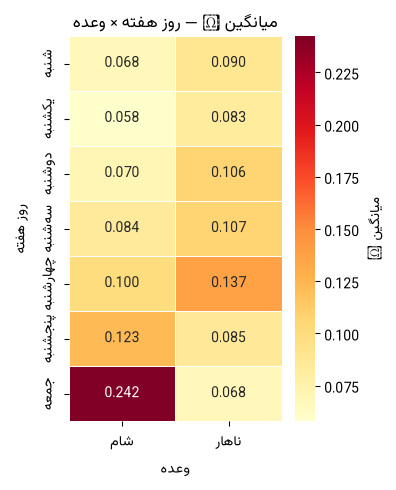

In [5]:
pt2 = df.pivot_table(index='dow_fa', columns='Meal', values='rho', aggfunc='mean')
pt2 = pt2.reindex([DOW_FA[i] for i in range(7)])

fig, ax = plt.subplots(figsize=(4, 5))
sns.heatmap(pt2, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.4,
            cbar_kws={'label': fa('میانگین ρ')}, ax=ax)
ax.set_title(fa('میانگین ρ — روز هفته × وعده'))
ax.set_xlabel(fa('وعده')); ax.set_ylabel(fa('روز هفته'))
ax.set_xticklabels([fa('شام' if t.get_text()=='dinner' else 'ناهار') for t in ax.get_xticklabels()])
ax.set_yticklabels([fa(t.get_text()) for t in ax.get_yticklabels()])
plt.tight_layout()
savefig('heatmap_dow_meal')
plt.show()

### Heatmap ۳ — ماه × وعده (میانگین $\rho$)

⚠️ خرداد ($n=71$، فقط ۱ روز از بازه) و شام در برخی ماه‌ها ($n$ کم) باید با احتیاط خوانده شوند.

saved: /home/mvajhi/code/new_project/reports/figures/4.2_heatmap_month_meal.png


/home/mvajhi/code/new_project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.canvas.draw()
/tmp/ipykernel_427465/2950985224.py:11: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  plt.tight_layout()
/tmp/ipykernel_427465/2359381861.py:42: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.savefig(path, dpi=150, bbox_inches='tight')
/home/mvajhi/code/new_project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.canvas.print_figure(bytes_io, **kw)


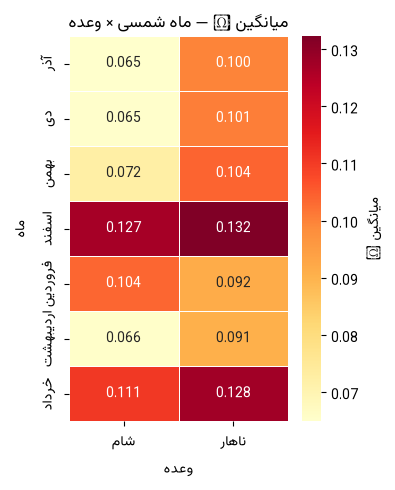

In [6]:
pt3 = df.pivot_table(index='month_fa', columns='Meal', values='rho', aggfunc='mean')
pt3 = pt3.reindex([MONTH_FA[m] for m in [9, 10, 11, 12, 1, 2, 3]])

fig, ax = plt.subplots(figsize=(4, 5))
sns.heatmap(pt3, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.4,
            cbar_kws={'label': fa('میانگین ρ')}, ax=ax)
ax.set_title(fa('میانگین ρ — ماه شمسی × وعده'))
ax.set_xlabel(fa('وعده')); ax.set_ylabel(fa('ماه'))
ax.set_xticklabels([fa('شام' if t.get_text()=='dinner' else 'ناهار') for t in ax.get_xticklabels()])
ax.set_yticklabels([fa(t.get_text()) for t in ax.get_yticklabels()])
plt.tight_layout()
savefig('heatmap_month_meal')
plt.show()

### Heatmap ۴ — سلف × روز هفته (میانگین $\rho$)

بررسی می‌کند آیا الگوی روز هفته (H2) در همه‌ی سلف‌ها یکسان است یا هر سلف الگوی خودش را دارد (تعامل سلف×روز، مرتبط با بند ۴.۹ WBS که به agent دیگری واگذار شده — اینجا فقط توصیفی).

/home/mvajhi/code/new_project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.canvas.draw()
/tmp/ipykernel_427465/1958073774.py:11: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  plt.tight_layout()
/tmp/ipykernel_427465/2359381861.py:42: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.savefig(path, dpi=150, bbox_inches='tight')


saved: /home/mvajhi/code/new_project/reports/figures/4.2_heatmap_restaurant_dow.png


/home/mvajhi/code/new_project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.canvas.print_figure(bytes_io, **kw)


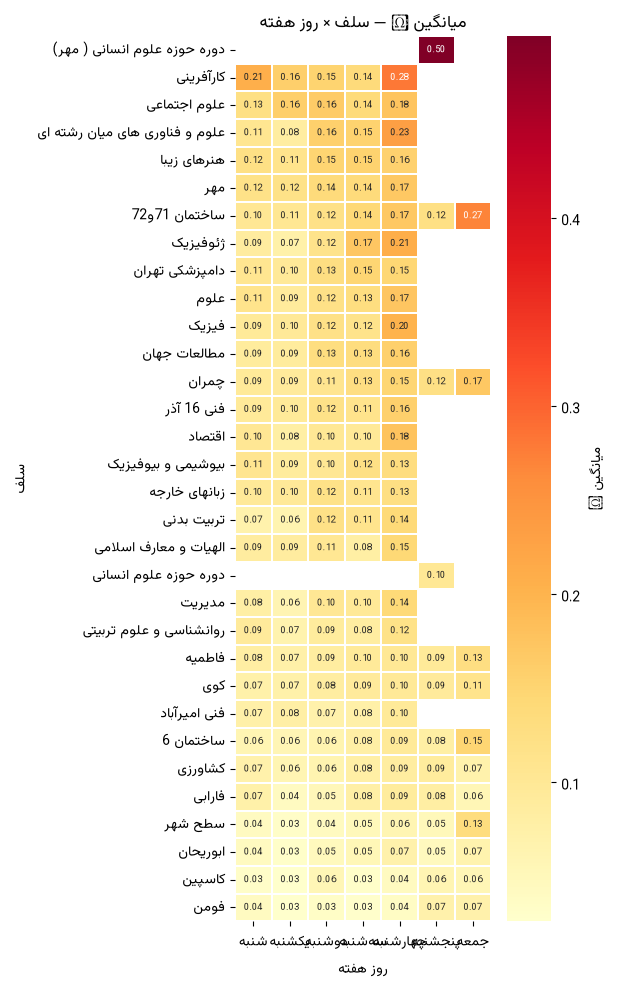

In [7]:
pt4 = df.pivot_table(index='RestaurantName', columns='dow_fa', values='rho', aggfunc='mean')
pt4 = pt4.reindex(index=piv_restaurant.index, columns=[DOW_FA[i] for i in range(7)])

fig, ax = plt.subplots(figsize=(6, 10))
sns.heatmap(pt4, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.3, annot_kws={'size': 7},
            cbar_kws={'label': fa('میانگین ρ')}, ax=ax)
ax.set_title(fa('میانگین ρ — سلف × روز هفته'))
ax.set_xlabel(fa('روز هفته')); ax.set_ylabel(fa('سلف'))
ax.set_xticklabels([fa(t.get_text()) for t in ax.get_xticklabels()])
ax.set_yticklabels([fa(t.get_text()) for t in ax.get_yticklabels()])
plt.tight_layout()
savefig('heatmap_restaurant_dow')
plt.show()

### Heatmap ۵ — نوع غذا × روز هفته (میانگین $\rho$)

برای H4 (خورشتی در برابر برنجی) — آیا اثر نوع غذا در طول هفته پایدار است؟

/home/mvajhi/code/new_project/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.canvas.draw()
/tmp/ipykernel_427465/2651999918.py:11: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  plt.tight_layout()
/tmp/ipykernel_427465/2359381861.py:42: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.savefig(path, dpi=150, bbox_inches='tight')
/home/mvajhi/code/new_project/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) Vazirmatn.
  fig.canvas.print_figure(bytes_io, **kw)


saved: /home/mvajhi/code/new_project/reports/figures/4.2_heatmap_foodtype_dow.png


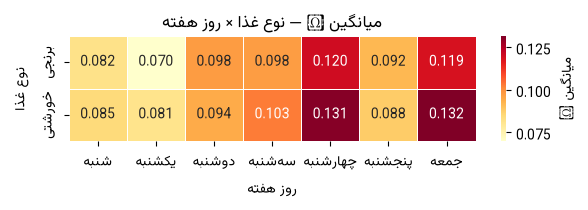

In [8]:
pt5 = df.pivot_table(index='FoodType', columns='dow_fa', values='rho', aggfunc='mean')
pt5 = pt5.reindex(columns=[DOW_FA[i] for i in range(7)])

fig, ax = plt.subplots(figsize=(6, 2.2))
sns.heatmap(pt5, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.4,
            cbar_kws={'label': fa('میانگین ρ')}, ax=ax)
ax.set_title(fa('میانگین ρ — نوع غذا × روز هفته'))
ax.set_xlabel(fa('روز هفته')); ax.set_ylabel(fa('نوع غذا'))
ax.set_xticklabels([fa(t.get_text()) for t in ax.get_xticklabels()])
ax.set_yticklabels([fa('خورشتی' if t.get_text()=='khorak' else 'برنجی') for t in ax.get_yticklabels()])
plt.tight_layout()
savefig('heatmap_foodtype_dow')
plt.show()

## ۴.۲.۲ – ۴.۲.۴ دفترچه فرضیه‌ها (H1–H12، پیش‌ثبت‌شده)

هر فرضیه در ادامه به همان صورتی که در جدول WBS آمده آزمون می‌شود. برای هر فرضیه: آزمون ناپارامتری انتخاب‌شده، آماره + p خام، اندازه‌ی اثر (Cliff's delta برای دو-گروهی، $\eta^2$ برای Kruskal-Wallis/Levene، $\rho_{spearman}$ برای همبستگی)، فاصله‌اطمینان bootstrap برای تفاوت میانه‌ها (وقتی دو-گروهی است)، و در دو مورد کلیدی (H1، H6) یک تکرار روی داده‌ی تجمیع‌شده در سطح سلف×روز برای بررسی نقض استقلال.

نتیجه‌ی هر آزمون در یک لیست جمع‌آوری می‌شود تا در پایان یک‌جا تصحیح FDR روی آن اعمال شود (سلول زیر).

In [9]:
# جمع‌آوری نتیجه‌ی سطح-فرضیه برای تصحیح FDR مشترک در پایان نوت‌بوک
hypothesis_results = []  # هر عضو: dict(id, hypothesis, test, statistic, p_raw, effect, effect_name, feature)

def register(hid, hypothesis, test, statistic, p_raw, effect, effect_name, feature, note=''):
    hypothesis_results.append(dict(
        id=hid, hypothesis=hypothesis, test=test, statistic=statistic,
        p_raw=p_raw, effect=effect, effect_name=effect_name, feature=feature, note=note
    ))
    print(f'[{hid}] {test}: statistic={statistic:.4g}  p_raw={p_raw:.4g}  {effect_name}={effect:.4g}')